# Week 8 Lab: Fine-tune a small LLM with LoRA for a domain task

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 3, 4

**Scenario.** A bank's support team wants incoming customer messages routed to the right intent. We adapt a small open LLM (**Qwen2.5-0.5B-Instruct**) to this domain and **measure** whether fine-tuning beats prompting.

1. Prepare a domain dataset (Banking77, 10 intents) in **chat format**, with a held-out test set.
2. Measure **prompting baselines** (zero-shot, few-shot) on the base model.
3. Add **LoRA** adapters with Hugging Face **PEFT** and count trainable parameters.
4. **Supervised fine-tuning** (SFT) with Hugging Face **TRL**.
5. Compare **base vs fine-tuned** on the same held-out test set; analyse errors.
6. Check for **forgetting**, switch the adapter off and on, and compare adapter size with model size.

**Runtime:** A GPU is recommended for the full lab. CPU training also works: on the laptop CPU used to check this pack, training took 53 to 76 minutes in two full runs, and the whole notebook about 84 minutes. Prepare the full run before class, or discuss the supplied recorded results. The tiny CPU smoke run uses six test messages, three training steps and batch size two to check the pipeline; its scores are not a quality comparison. Time depends on your hardware.

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **GPU** if available. A T4 is sufficient for the GPU examples. Free GPU access varies. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. Read this week's runtime note. Model downloads and training can take longer on CPU, and some full experiments need a GPU.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete before running dependent cells. Questions marked ✍️ need a short written answer.
> - Read each diagram by following its numbered blocks. The solid arrows carry data to the next block. A dashed arrow shows a step that repeats.

## This week's place in the course

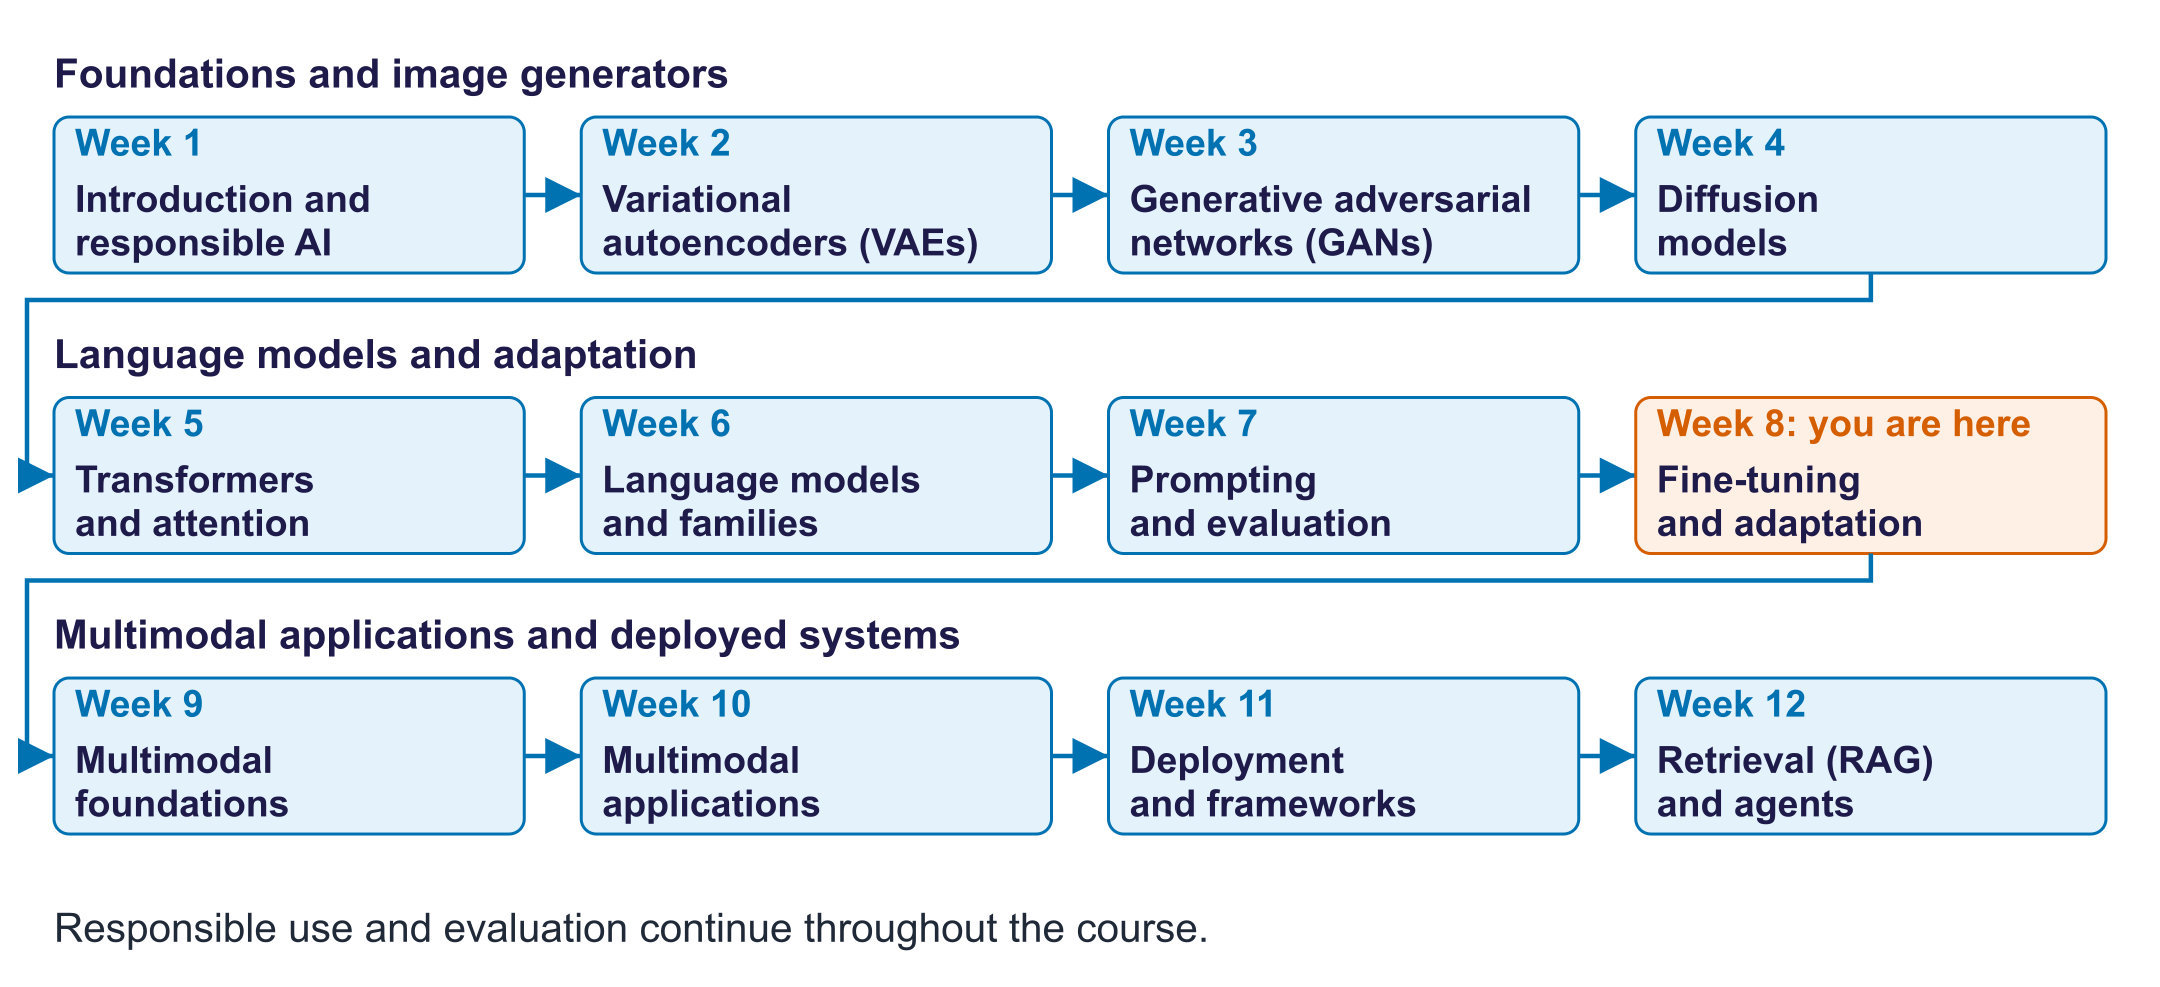

## Start here: what changes during fine-tuning?

Customer messages and known intent labels become training pairs. A pretrained
model already supplies general language patterns. LoRA freezes its base
weights and adds small trainable correction matrices. Supervised fine-tuning
uses the known label tokens to teach those corrections. The test set checks
whether the resulting classifier improves on the prompting baselines.

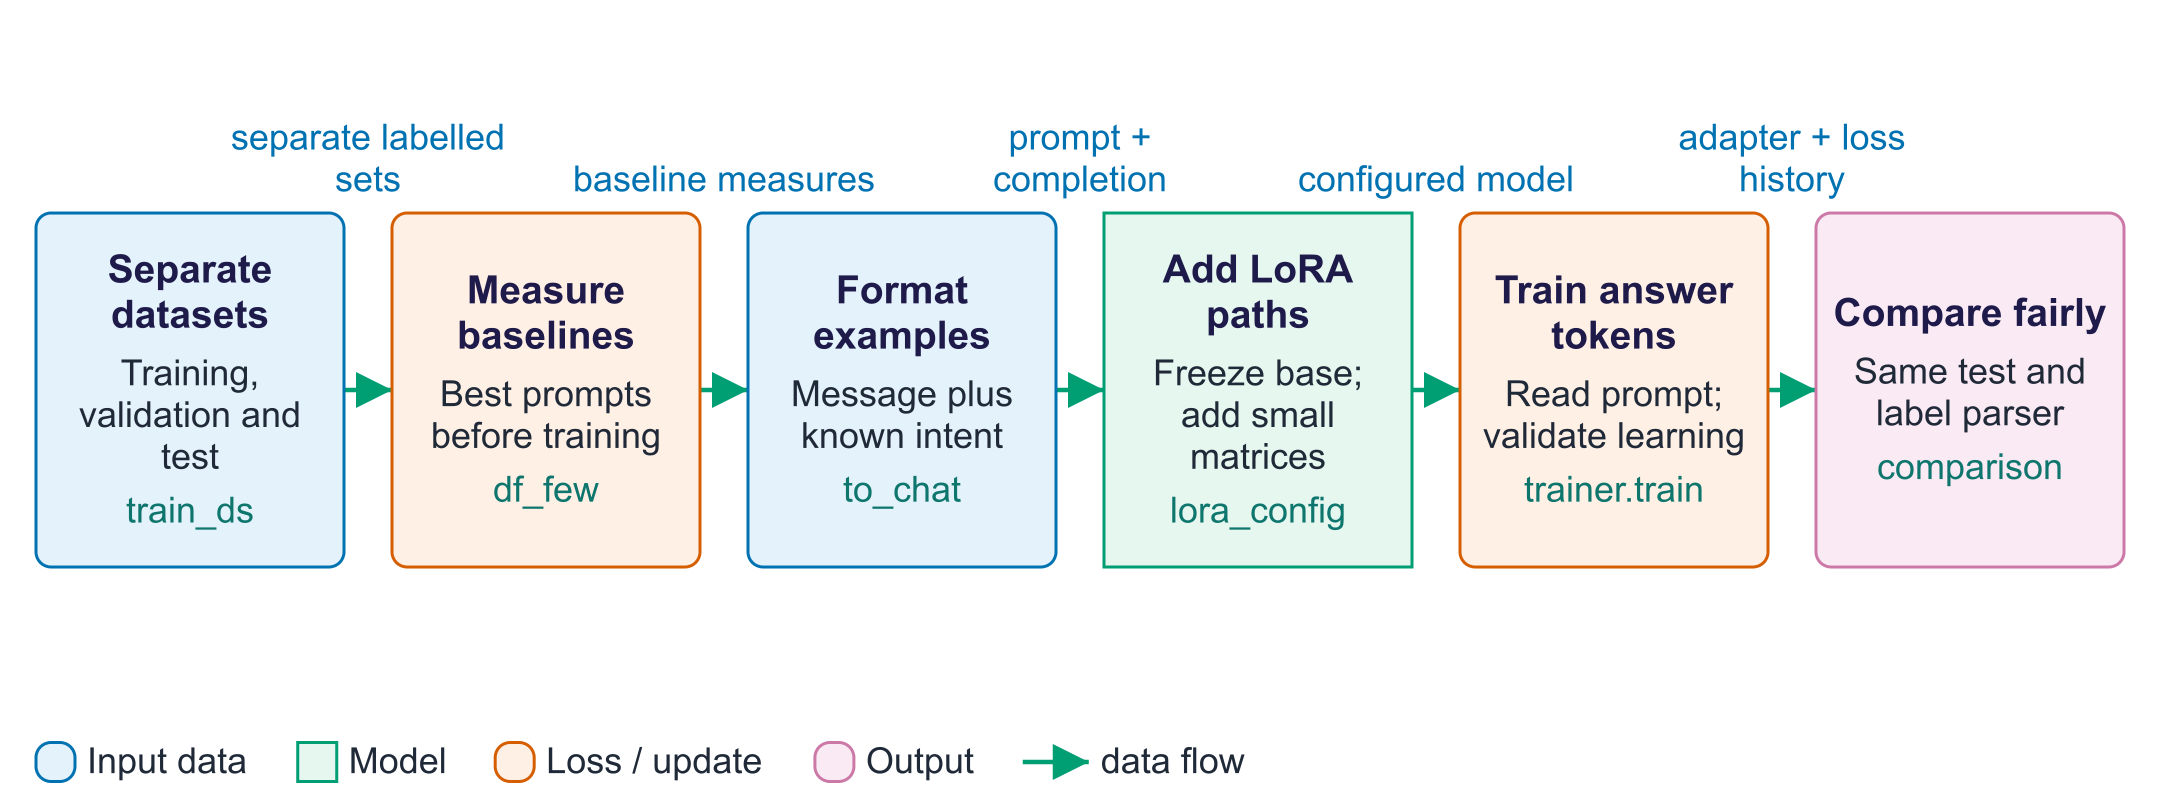

## Your map from the workflow to code

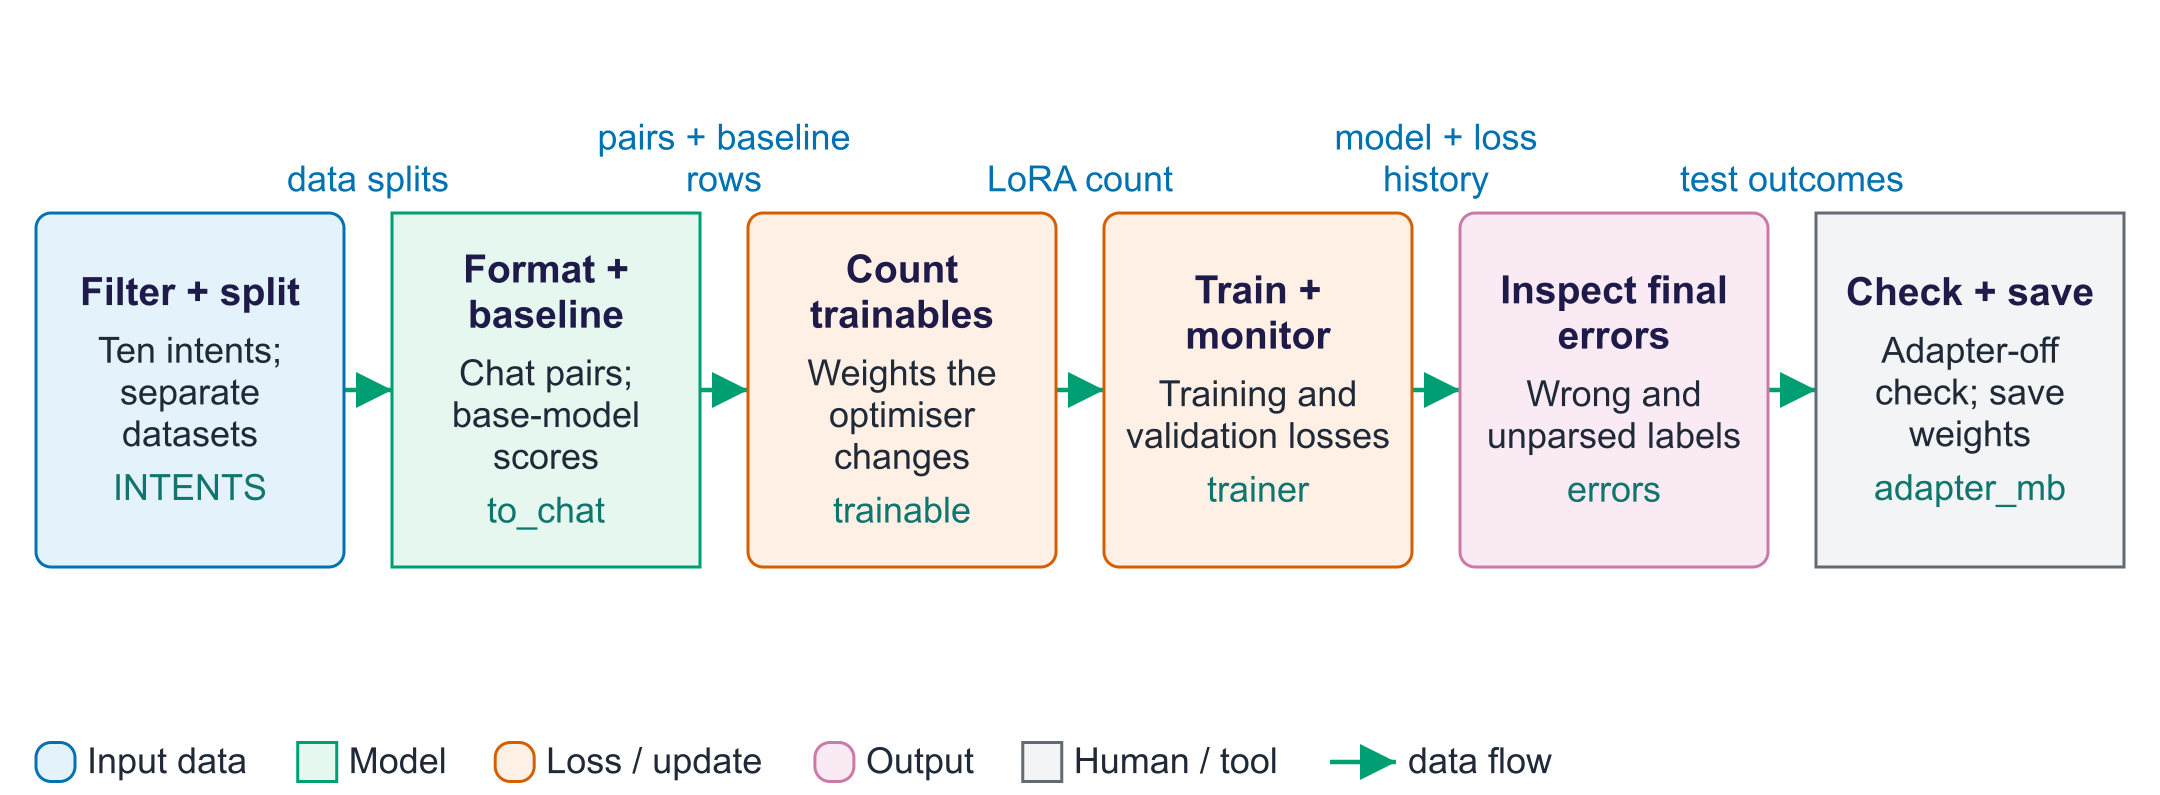

| Block in the map | Find this code | Observe this |
|---|---|---|
| Filter and split | `INTENTS`, `train_ds`, `val_ds`, `test_ds` | Which examples serve each purpose |
| Format and baseline | `to_chat`, `evaluate` | Prompt/completion boundaries and base predictions |
| Count trainables | `lora_config`, `trainable`, `total` | Which parameters can change |
| Train and monitor | `trainer`, `hist` | Training and validation loss together |
| Inspect test errors | `comparison`, `errors` | Valid labels, wrong decisions and unparsed outputs |
| Check and save | `disable_adapter`, `save_pretrained` | Active-adapter behaviour and the saved artifact |

SFT names the training objective and example format; LoRA names the parameter
update method. They work together here. A lower training loss is useful
evidence of learning, but held-out decisions determine task performance.

**Read:** an **intent** is the kind of help a customer wants. A **baseline**
is the result before training. An **adapter** is a small set of added weights.
**Run:** prepare the split and format, measure the base model, then train.
**Change:** after training, switch the adapter off and on for the same input.
**Check:** compare all models on the same test messages using the same parser.
Use the training set to learn and the validation set to choose settings;
keep the test set for the final check. Do not tune repeatedly on test errors.

**What/why:** Install model, data, adapter and training libraries.
**Expected output:** Successful imports after installation.
**Predict/check:** The lab updates adapters rather than pre-training a model.

In [ ]:
%pip install -q transformers accelerate datasets peft trl pandas matplotlib

**What/why:** Choose hardware, seed and the base model.
**Expected output:** Device and shared run settings.
**Predict/check:** Smoke results are execution checks, not lecture-quality measurements.

In [ ]:
import os
import random
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import Dataset, load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
random.seed(0)
torch.manual_seed(0)
print("device:", DEVICE)

## Part 1 · Domain data in chat format

Banking77 contains real customer-support messages labelled with 77 intents (licence CC-BY-4.0). We use **10 intents**.

**What/why:** Filter ten intents and create separate data splits.
**Expected output:** Training, validation and test sizes.
**Predict/check:** Check no final-test messages or near-duplicates enter learning.

In [ ]:
INTENTS = ["card_arrival", "lost_or_stolen_card", "exchange_rate", "top_up_failed", "pending_transfer",
           "activate_my_card", "cash_withdrawal_charge", "verify_my_identity", "age_limit", "Refund_not_showing_up"]
raw = load_dataset("mteb/banking77")
keep = lambda ex: ex["label_text"] in INTENTS  # noqa: E731
train_full = raw["train"].filter(keep).shuffle(seed=0)
test_full = raw["test"].filter(keep).shuffle(seed=0)
split = train_full.train_test_split(test_size=0.1, seed=0)
# Validation comes from the training source; test_full remains a separate source.
train_ds, val_ds = split["train"], split["test"]
N_TEST = 6 if SMOKE else 200  # exercise the whole pipeline without a long CPU evaluation
test_ds = test_full.select(range(N_TEST))
print(f"train {len(train_ds)} | validation {len(val_ds)} | test {len(test_ds)}")
pd.Series(train_ds["label_text"]).value_counts()

**TODO 1:** write `to_chat(example)` returning a **prompt–completion** pair in conversational form:

* `prompt`: a list with one user message: `"Classify the banking customer message into one intent.\nIntents: <comma-separated list>\nMessage: <text>\nIntent:"`
* `completion`: a list with one assistant message whose content is the intent label.

TRL trains only on the **completion** tokens (the prompt is masked out of the loss).
A training record is a conversation with a known answer. The user message
asks for a category; the assistant message supplies the labelled category.
Do not put the correct label into the user prompt used for evaluation: the
model must predict it. A label may span several tokens, even if it looks like
one short word to us.

**What/why:** Format a message and its known answer as chat pairs.
**Expected output:** A prompt/completion example.
**Predict/check:** The template and answer boundaries define which tokens receive loss.

In [ ]:
INSTRUCTION = "Classify the banking customer message into one intent.\nIntents: " + ", ".join(INTENTS)


def to_chat(example):
    return {"prompt": [{"role": "user", "content": f"{INSTRUCTION}\nMessage: {example['text']}\nIntent:"}],
            "completion": [{"role": "assistant", "content": example["label_text"]}]}


sft_train = train_ds.map(to_chat, remove_columns=train_ds.column_names)
sft_val = val_ds.map(to_chat, remove_columns=val_ds.column_names)
print(sft_train[0])

## Part 2 · Baselines: prompting the base model

We reuse the idea of last week's harness: fixed model, greedy decoding, exact-match accuracy on the held-out test set.

**What/why:** Run zero-shot and few-shot base-model baselines.
**Expected output:** Accuracy, parse failures and timing rows.
**Predict/check:** Fine-tuning must beat the best prompting baseline on this same test.

In [ ]:
tok = AutoTokenizer.from_pretrained(MODEL_ID)
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE).eval()


@torch.no_grad()
def predict(model, messages, max_new_tokens=32):
    inputs = tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()


# A lenient parser, so the baselines are not punished for wrapping the label in a sentence ("Intent: age_limit",
# "The intent is \"age limit\""): the prediction is the first intent label mentioned, with spaces or underscores.
LABEL_RE = {lab: re.compile(r"(?<![a-z])" + lab.lower().replace("_", "[ _]") + r"(?![a-z])") for lab in INTENTS}


def normalise(text):
    hits = [(m.start(), lab) for lab, pattern in LABEL_RE.items() if (m := pattern.search(text.lower()))]
    return min(hits)[1] if hits else None


def evaluate(model, make_messages, ds=test_ds, name=""):
    rows = []
    t0 = time.time()
    for ex in ds:
        raw_out = predict(model, make_messages(ex))
        # Recognition is defined by our lenient parser; it is not strict label-only output.
        pred = normalise(raw_out)
        rows.append({"text": ex["text"], "gold": ex["label_text"], "raw": raw_out, "pred": pred, "correct": pred == ex["label_text"]})
    df = pd.DataFrame(rows)
    print(f"{name:22s} accuracy {df.correct.mean():.3f} | invalid {df.pred.isna().mean():.3f} | {time.time() - t0:.0f} s")
    return df


zero = lambda ex: to_chat(ex)["prompt"]  # noqa: E731
shots = {}
for ex in train_ds:
    shots.setdefault(ex["label_text"], ex["text"])
SHOTS = "\n".join(f"Message: {t}\nIntent: {l}" for l, t in shots.items())
few = lambda ex: [{"role": "user", "content": f"{INSTRUCTION}\n\nExamples:\n{SHOTS}\n\nMessage: {ex['text']}\nIntent:"}]  # noqa: E731

df_zero = evaluate(base, zero, name="base, zero-shot")
df_few = evaluate(base, few, name="base, few-shot (10 ex.)")

**What/why:** Inspect mistakes made before training.
**Expected output:** Raw wrong-label and unparsed replies.
**Predict/check:** A parser failure differs from a wrong recognised intent.

In [ ]:
# What did the base model actually write? A missing label (pred = None) is a format failure; a wrong label is a decision failure.
pd.concat([df_zero.assign(prompt="zero-shot"), df_few.assign(prompt="few-shot")]).groupby("prompt").head(4)[["prompt", "gold", "raw", "pred"]]

## Part 3 · Add LoRA adapters

LoRA freezes the pretrained weight $W$ and learns a low-rank update $\Delta W = \frac{\alpha}{r} B A$ with $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$.

**TODO 2:** create a `LoraConfig` with rank `r=16`, `lora_alpha=32`, `lora_dropout=0.05`, applied to the attention projections `q_proj, k_proj, v_proj, o_proj`, task type `CAUSAL_LM`. Then print the number of trainable parameters.

**Read the matrix shapes:** `W` maps `k` input features to `d` output features.
`A` maps `k` features to `r`, then `B` maps those `r` features to `d`.
The adapter learns `r*k + d*r` numbers instead of `d*k` for a full update.
`alpha/r` scales its contribution; here it is `32/16=2`. These symbols have
different meanings from diffusion's alpha and beta. Only the added matrices
learn in this configuration; the original `W` stays fixed.

**What/why:** Configure LoRA and count trainable versus total weights.
**Expected output:** The exact configured adapter parameter count.
**Predict/check:** Do not estimate another rank/module count by dividing this result.


### A LoRA training update
Trace information forward and learning backward while the base stays frozen

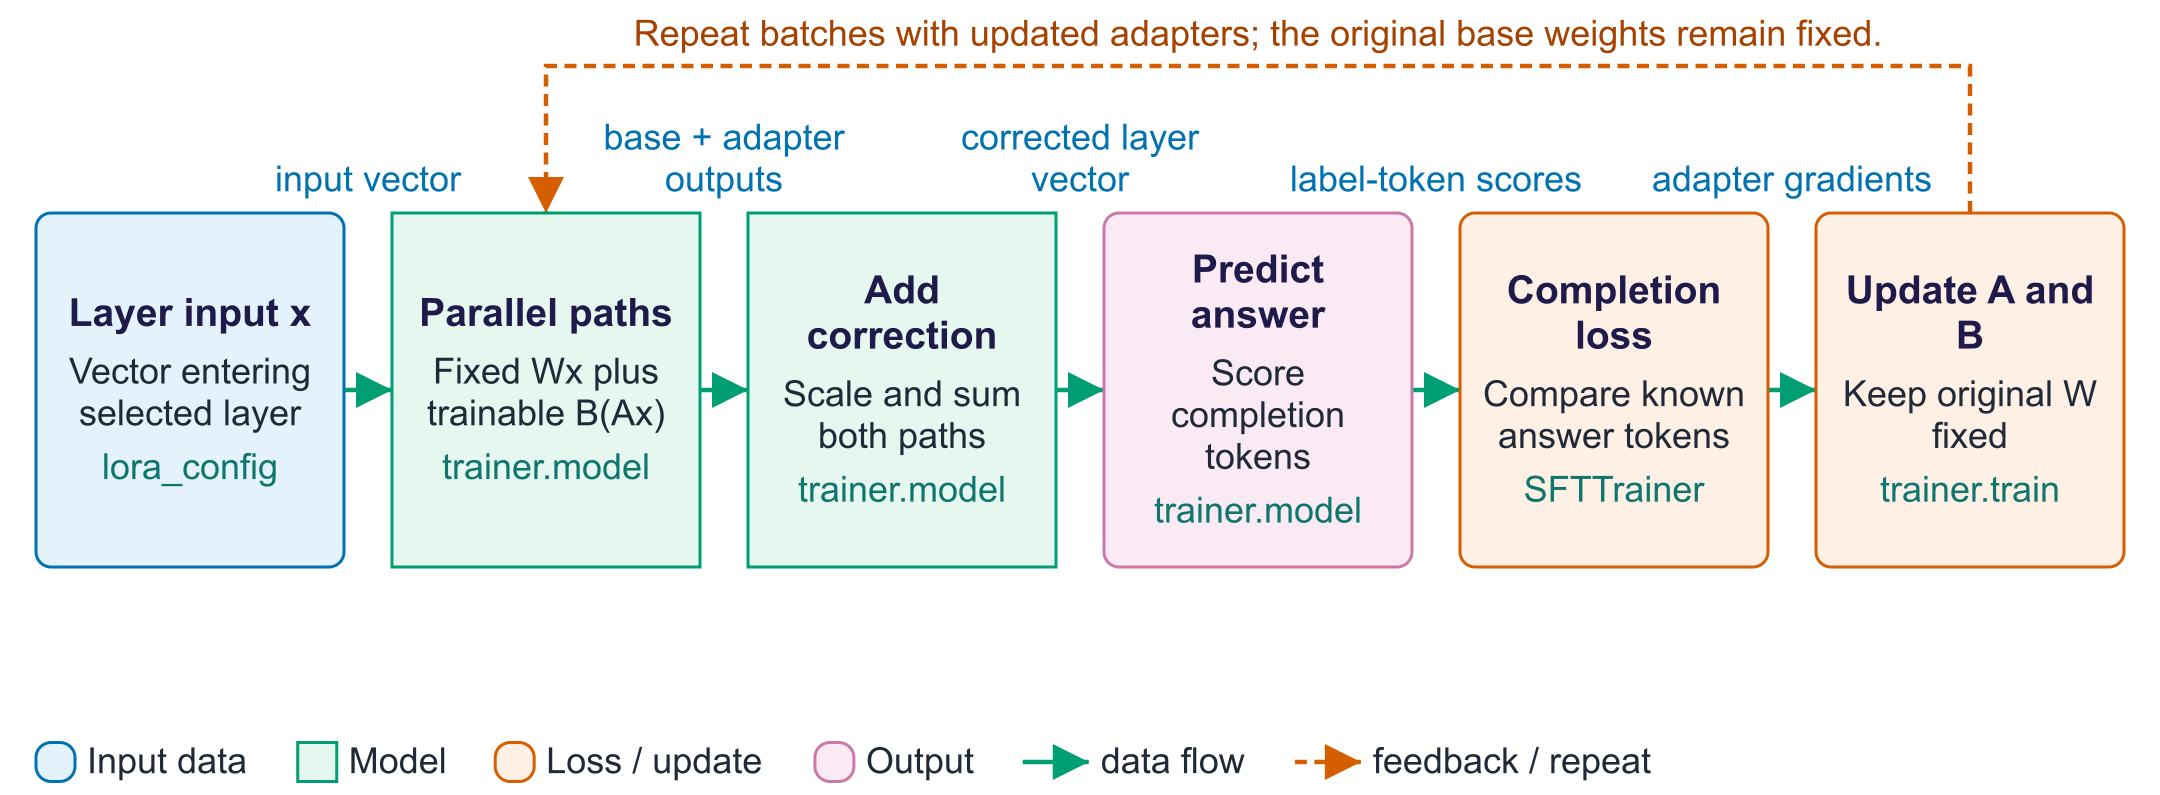

1. For an illustrative 8-input, 8-output projection, the frozen W has 64 entries.
2. Rank r=2 uses A with shape [2, 8] and B with shape [8, 2]: 32 trainable entries total.
3. W x and B(Ax) are parallel contributions; the adapter is not a layer after W.
4. Their summed output feeds the remaining network and its completion-token loss.
5. The optimizer updates A and B, while W keeps its pretrained values.

**Predict before running:** Does the adapter take W x as its input, or does it use the same x as the base projection?

**✅ Model answer:**
**Instructor explanation:** It uses the same x. The base and adapter paths run in parallel and their outputs are added.

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
                         bias="none", task_type="CAUSAL_LM")

probe = get_peft_model(AutoModelForCausalLM.from_pretrained(MODEL_ID), lora_config)
trainable = sum(p.numel() for p in probe.parameters() if p.requires_grad)
total = sum(p.numel() for p in probe.parameters())
print(f"trainable parameters: {trainable:,} of {total:,} ({100 * trainable / total:.2f}%)")
del probe

## Part 4 · Supervised fine-tuning with TRL

`SFTTrainer` applies the chat template, masks the prompt, and trains only the LoRA parameters.

The completion is the known intent label, possibly represented by several
tokens. Loss evaluates those tokens. The prompt supplies context but is
excluded from that loss. Monitor validation loss alongside training loss;
validation evaluation is omitted by the short smoke-test configuration.
**Check the training log:** `step` counts optimiser updates, not examples.
Training and validation losses appear on different rows because they are
measured at different times. Lower training loss means the model fits its
examples more closely; validation and test results show whether that learning
helps on other messages.

**What/why:** Train on completion tokens and monitor validation.
**Expected output:** Measured minutes and training/validation loss curves.
**Predict/check:** Falling loss is evidence to inspect alongside held-out task behaviour.


### From examples to a saved adapter
Training changes LoRA weights; validation helps choose when to stop

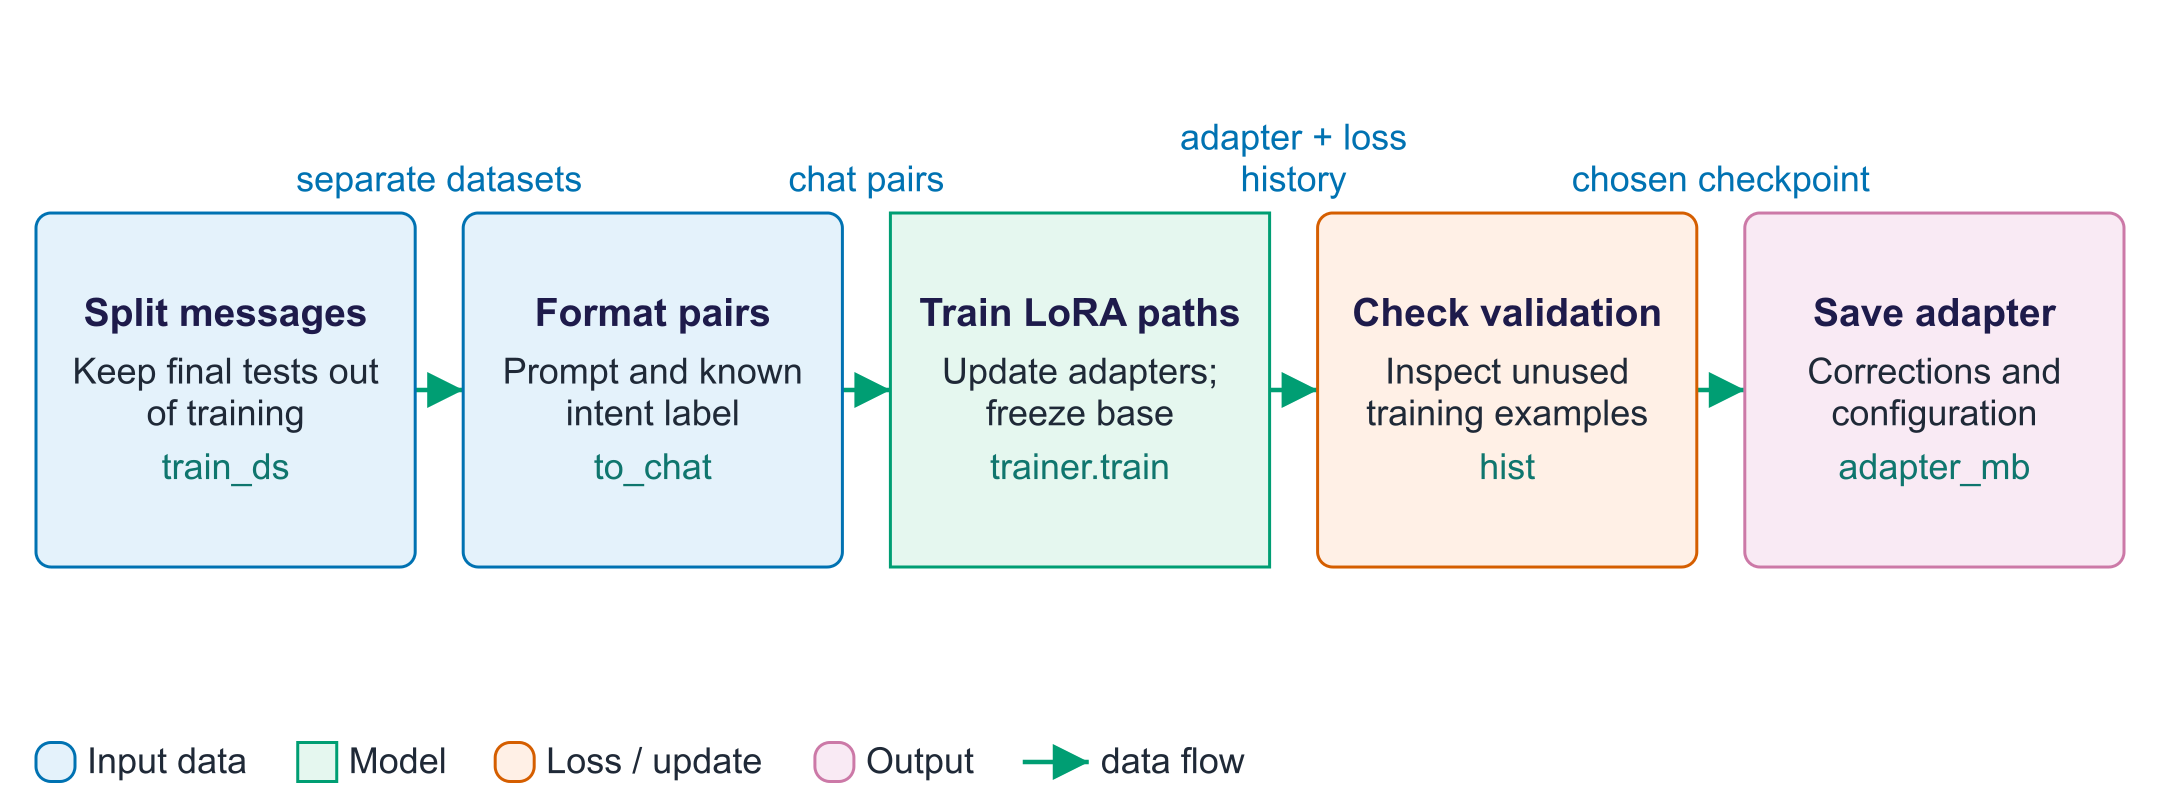

1. A training message about a missing card payment has a known intent label.
2. to_chat pairs the message prompt with that label as the completion.
3. The trainer changes adapter weights to reduce answer-token loss.
4. If validation loss rises while training loss falls, investigate overfitting.
5. Save the adapter with its base-model identity and settings.

**Predict before running:** Does a small adapter file contain the whole model?

**✅ Model answer:**
**Instructor explanation:** No. It contains added weights and configuration; load the compatible base model too.

In [ ]:
from trl import SFTConfig, SFTTrainer

args = SFTConfig(
    output_dir="banking-lora",
    num_train_epochs=1,
    max_steps=3 if SMOKE else -1,
    per_device_train_batch_size=2 if SMOKE else 16,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=5,
    logging_steps=1 if SMOKE else 5,
    eval_strategy="steps" if not SMOKE else "no",
    eval_steps=20,
    max_length=256,
    completion_only_loss=True,  # learn answer tokens while reading the prompt
    eos_token="<|im_end|>",     # Qwen chat turn-end token
    save_strategy="no",
    report_to="none",
    fp16=False,
    bf16=False,
    seed=0,
)
ft_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)
trainer = SFTTrainer(model=ft_model, args=args, train_dataset=sft_train, eval_dataset=None if SMOKE else sft_val,
                     peft_config=lora_config, processing_class=tok)
t0 = time.time()
trainer.train()
train_minutes = (time.time() - t0) / 60
print(f"training took {train_minutes:.1f} min")

hist = pd.DataFrame(trainer.state.log_history)
# Training and validation entries occur on different rows of the log history.
plt.plot(hist.dropna(subset=["loss"]).step, hist.dropna(subset=["loss"]).loss, label="train loss")
if "eval_loss" in hist:
    ev = hist.dropna(subset=["eval_loss"])
    plt.plot(ev.step, ev.eval_loss, marker="o", label="validation loss")
plt.xlabel("step"); plt.ylabel("loss (completion tokens)"); plt.legend(); plt.title("LoRA SFT"); plt.show()

## Part 5 · Base vs fine-tuned on the same held-out test set

**TODO 3:** evaluate the fine-tuned model with the **zero-shot** prompt (the format it was trained on) and build a comparison table of the three results.

**What/why:** Evaluate the trained adapter on the same final messages.
**Expected output:** Three-model comparison table.
**Predict/check:** Keep parser, test messages and decoding settings comparable.


### Use and check the adapted classifier
Prediction uses the same chat format, without gradient updates

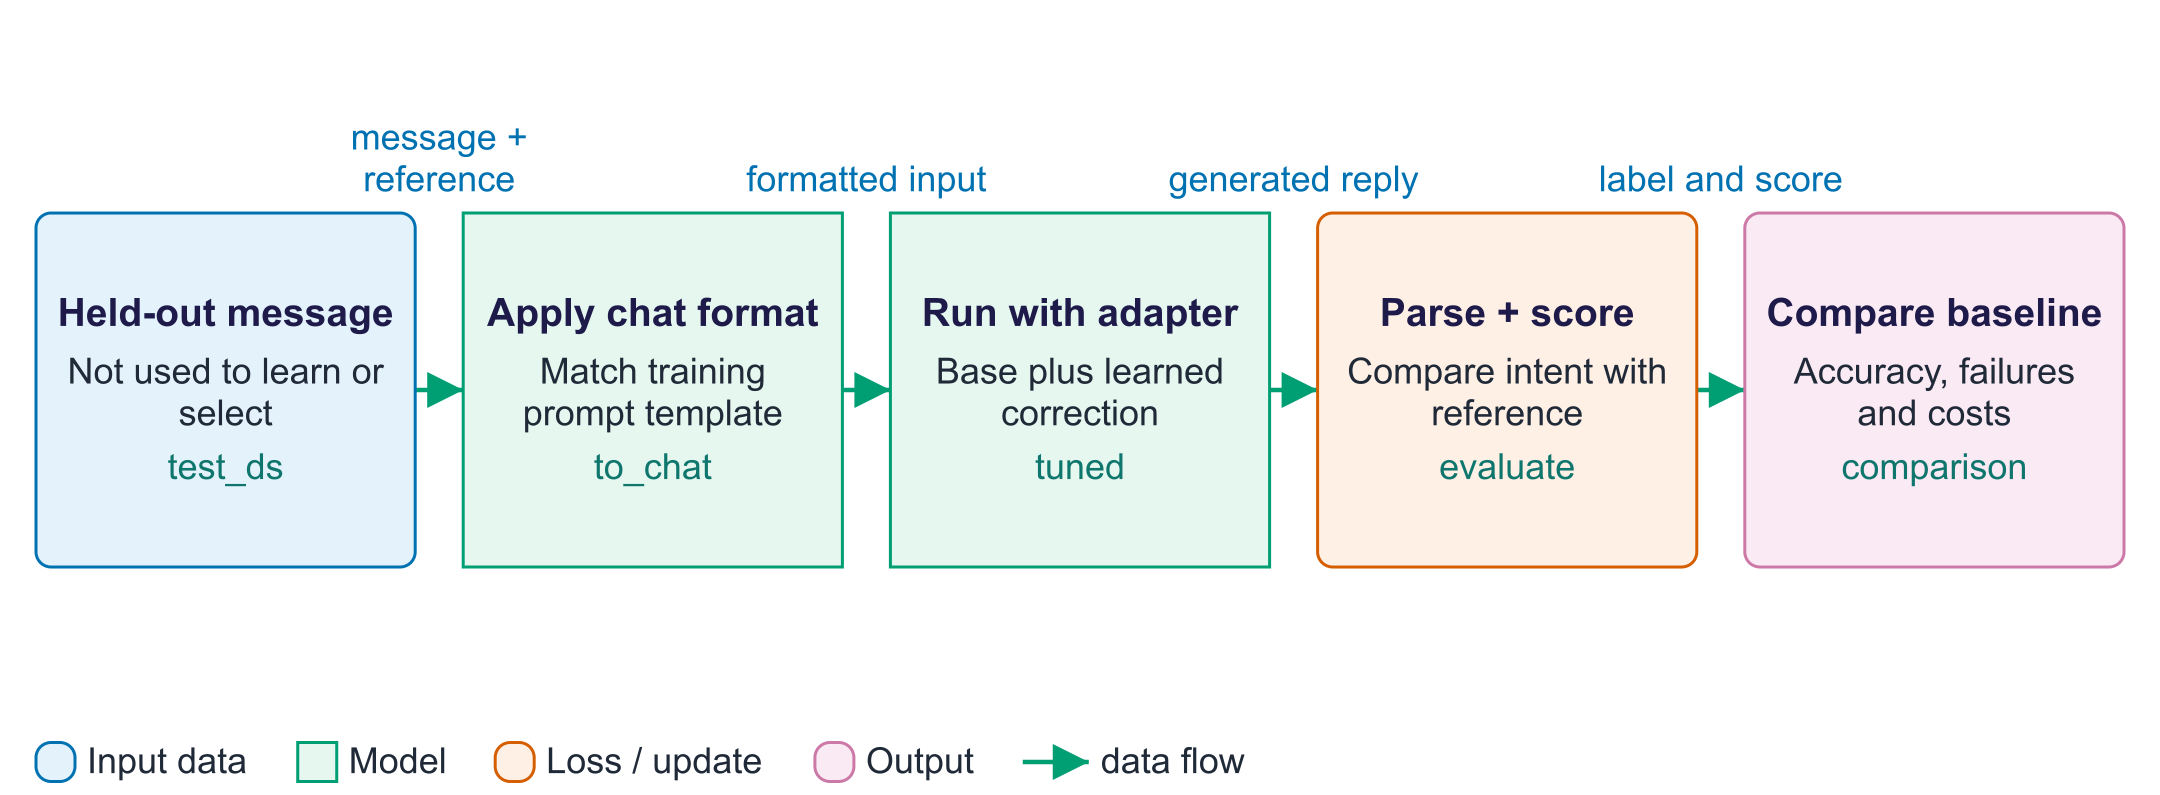

1. Choose a held-out message about a charged fee.
2. Run the base few-shot prompt and adapted model on that same text.
3. Inspect raw replies, parsed labels and the reference together.
4. Record task accuracy and repeat a small general-ability check.

**Predict before running:** Why use the same parser for base and adapted answers?

**✅ Model answer:**
**Instructor explanation:** Otherwise a score difference could come from different checking rules rather than the model.

In [ ]:
tuned = trainer.model.eval()
df_tuned = evaluate(tuned, zero, name="LoRA fine-tuned")
comparison = pd.DataFrame([
    {"model": "base, zero-shot", "accuracy": df_zero.correct.mean(), "invalid": df_zero.pred.isna().mean()},
    {"model": "base, few-shot", "accuracy": df_few.correct.mean(), "invalid": df_few.pred.isna().mean()},
    {"model": "LoRA fine-tuned", "accuracy": df_tuned.correct.mean(), "invalid": df_tuned.pred.isna().mean()},
])
comparison

**What/why:** Read remaining fine-tuned mistakes.
**Expected output:** Raw error rows.
**Predict/check:** High accuracy can still hide costly failure categories.

In [ ]:
errors = df_tuned[~df_tuned.correct]
print(f"{len(errors)} errors")
errors[["text", "gold", "raw"]].head(10)

**What/why:** Group predictions and references into a confusion table.
**Expected output:** Per-intent counts plus an INVALID column.
**Predict/check:** Locate category confusion instead of only reporting an average.

In [ ]:
pd.crosstab(df_tuned.gold, df_tuned.pred.fillna("INVALID"))

✍️ **Question 1.** Compare the three rows. Did fine-tuning help, and by how
much? Look at the remaining errors: are they model errors or ambiguous labels?
Would the conclusion change with a larger or a different test set?

**✅ Model answer:**
Report this run's accuracies and invalid-output rates; fine-tuning is not guaranteed to win. Few-shot examples can clarify the labels without training. SFT can teach the label format and the differences between similar intents, while avoiding the need to send ten examples in every future prompt. Inspect mistakes such as card_arrival versus activate_my_card to separate wrong decisions from ambiguous wording. The parser is lenient, so a sentence containing a recognised label can count as correct even when it is not label-only output. With 200 items, one changed prediction is 0.5 percentage points, and small gaps still need uncertainty estimates or repeated evaluation. A new period, channel or customer population may change the result.

## Part 6 · Forgetting, modularity and size

What happens if we ask the fine-tuned model an ordinary question? LoRA keeps the base weights frozen, so we can **switch the adapter off**.
This single question illustrates possible specialisation. It is not a broad
benchmark of retained general capabilities; use a varied regression set for that.

**What/why:** Ask a general question with the adapter on and off.
**Expected output:** Two replies from one base model.
**Predict/check:** One question illustrates drift; it is not a complete earlier-ability test.

In [ ]:
q = [{"role": "user", "content": "In one sentence, what is the capital of France and why is it famous?"}]
print("fine-tuned (adapter on): ", predict(tuned, q, max_new_tokens=40))
with tuned.disable_adapter():
    print("adapter switched off:    ", predict(tuned, q, max_new_tokens=40))

**TODO 4:** save the adapter and compare its size on disk with the size of the full model's weights.
The adapter measure below counts files on disk; the base measure counts
parameter bytes in memory. Report those definitions with the numbers.

**What/why:** Save added weights and count their actual file size.
**Expected output:** Adapter directory and measured megabytes.
**Predict/check:** Load it with the matching base; rollback also changes deployment configuration.

In [ ]:
tuned.save_pretrained("banking-lora-adapter")
adapter_mb = sum(os.path.getsize(os.path.join("banking-lora-adapter", f)) for f in os.listdir("banking-lora-adapter")) / 1e6
model_mb = sum(p.numel() * p.element_size() for p in base.parameters()) / 1e6
print(f"adapter: {adapter_mb:.1f} MB | full model weights (fp32): {model_mb:.0f} MB")

✍️ **Question 2.** What did the fine-tuned model do with the general question, and why? How does LoRA's modularity help in practice (think of one base model serving several departments)?

**✅ Model answer:**
With the adapter on, the model often answers with an intent label or a very short banking-style output: it has specialised to the narrow training format (a form of catastrophic forgetting / over-specialisation). With the adapter switched off, the frozen base model answers normally, because LoRA never changed the original weights. In practice one base model can be loaded once and several small adapters (a few MB each) can be swapped per request or department (support routing, HR, legal drafting), which saves memory and makes rollback trivial. To reduce forgetting when a single model must stay general, mix general instruction data into the fine-tuning set, lower the learning rate or number of epochs, and evaluate general capability alongside the task metric.

## Optional extensions

**QLoRA (GPU only).** Load the base model in 4-bit and train LoRA on top:

```python
from transformers import BitsAndBytesConfig
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", quantization_config=bnb, device_map="auto")
```

**DPO (preference tuning).** With a dataset of `prompt`, `chosen`, `rejected` examples:

```python
from trl import DPOConfig, DPOTrainer
trainer = DPOTrainer(model=model, args=DPOConfig(output_dir="dpo", beta=0.1), train_dataset=prefs, processing_class=tok, peft_config=lora_config)
```

✍️ **Question 3.** Your team is choosing between (a) few-shot prompting a large API model and (b) this LoRA-tuned 0.5B model for routing 50,000 messages per day. Compare them on accuracy, cost, latency, privacy and maintenance.

**✅ Model answer:**
(a) A large API model with few-shot prompts may reach high accuracy without training, updates are easy (edit the prompt), but it costs per token for 50,000 long prompts per day (the label list and examples are resent each time), adds network latency, sends customer data to a third party (GDPR and contract review needed) and depends on the provider's model versions. (b) The LoRA-tuned small model needs labelled data and a training/evaluation pipeline, but inference is cheap and fast on modest hardware, data stays in-house, the version is fixed, and the adapter is small and easy to roll back; it must be re-trained when intents change and monitored for drift. For high-volume, stable, privacy-sensitive classification, (b) is usually preferable if its measured accuracy meets the bar; (a) is attractive for prototyping or rapidly changing categories.

**What/why:** Optionally export measured results and provenance.
**Expected output:** A JSON file only when a path is supplied.
**Predict/check:** Preserve real counts, hardware, minutes, sizes and run settings.

In [ ]:
# Instructor tooling: save measured results for the lecture slides (only when requested).
if os.environ.get("GENAI_RESULTS_PATH"):
    import json
    loss_hist = hist.dropna(subset=["loss"])[["step", "loss"]].to_dict("list")
    eval_hist = hist.dropna(subset=["eval_loss"])[["step", "eval_loss"]].to_dict("list") if "eval_loss" in hist else {}
    payload = {"model": MODEL_ID, "n_train": len(train_ds), "n_test": len(test_ds), "trainable": trainable, "total": total,
               "train_minutes": train_minutes, "device": DEVICE, "comparison": comparison.to_dict("records"),
               "adapter_mb": adapter_mb, "model_mb": model_mb, "loss": loss_hist, "eval": eval_hist}
    with open(os.environ["GENAI_RESULTS_PATH"], "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=float)
    print("results saved")

## What we learned: fine-tuning

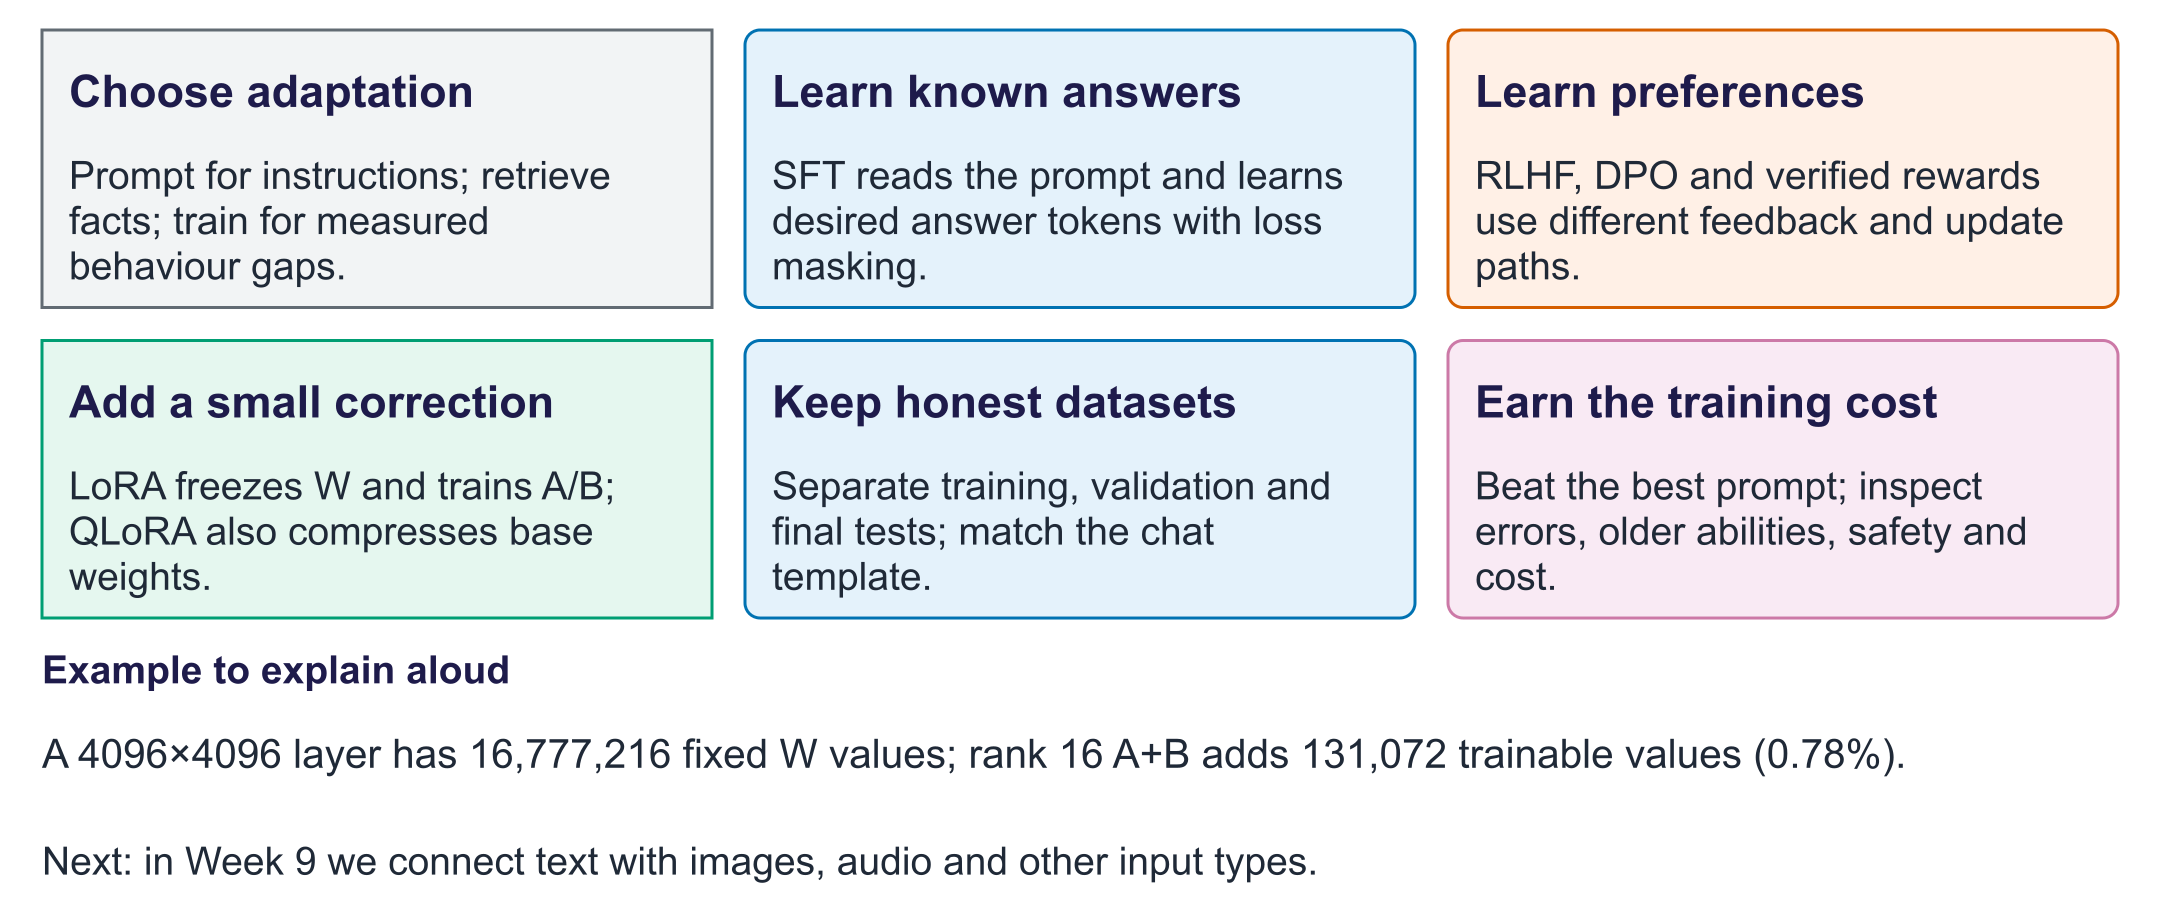

A 4096×4096 layer has 16,777,216 fixed W values; rank 16 A+B adds 131,072 trainable values (0.78%).

**Explain without looking:** Does falling training loss prove that fine-tuning helped?

**Instructor answer:** No. Compare with the best prompt on held-out examples; inspect errors, validation, earlier abilities and cost.